# HormuzWatch — Difference-in-Differences Analysis
**Treatment unit:** Oil (Brent + WTI) — Hormuz-exposed  
**Control units:** Non-Hormuz energy (Henry Hub Nat Gas, Coal Sector ETF)  
**Treatment date:** 2026-02-28 (US-Israel strikes on Iran)  
**Identification assumption:** In the absence of the treatment, oil prices would have followed the same trend as non-Hormuz energy commodities.

Charts: `outputs/charts/did_parallel_trends.png` · `outputs/charts/did_results.png`

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
import statsmodels.formula.api as smf
import statsmodels.api as sm
from linearmodels.panel import PanelOLS

ROOT      = Path('..').resolve()
PROCESSED = ROOT / 'data' / 'processed'
CHARTS    = ROOT / 'outputs' / 'charts'
CHARTS.mkdir(parents=True, exist_ok=True)

EVENT_DATE  = pd.Timestamp('2026-02-28')   # US-Israel strikes
HORMUZ_DATE = pd.Timestamp('2026-03-07')   # Hormuz closure (1st trading day: Mar 9)
BASE_DATE   = pd.Timestamp('2026-01-01')   # nominal index base (actual: Jan 2)

BG=     '#11111b'
SURFACE='#1e1e2e'
BORDER= '#313244'
TEXT=   '#cdd6f4'
SUBTEXT='#a6adc8'
MUTED=  '#585b70'

C_OIL  = '#f9e2af'   # gold — treated (oil)
C_CTRL = '#89b4fa'   # blue — control (nat gas + coal)
C_DIFF = '#a6e3a1'   # green — differential

def apply_style(ax, title='', xlabel='', ylabel=''):
    ax.set_facecolor(SURFACE); ax.figure.set_facecolor(BG)
    for sp in ax.spines.values(): sp.set_edgecolor(BORDER)
    ax.tick_params(colors=SUBTEXT, labelsize=9)
    ax.xaxis.label.set_color(SUBTEXT); ax.yaxis.label.set_color(SUBTEXT)
    ax.set_title(title, color=TEXT, fontsize=11, pad=8, loc='left', fontweight='bold')
    ax.set_xlabel(xlabel, fontsize=9); ax.set_ylabel(ylabel, fontsize=9)
    ax.grid(False); return ax

plt.rcParams.update({'font.family':'monospace','text.color':TEXT,
    'axes.labelcolor':SUBTEXT,'xtick.color':SUBTEXT,'ytick.color':SUBTEXT,
    'figure.facecolor':BG,'axes.facecolor':SURFACE,'axes.edgecolor':BORDER})
print('Imports OK')

Imports OK


## 1. Construct DiD panel

In [2]:
TREAT_COMMS = ['Brent Crude', 'WTI Crude']
CTRL_COMMS  = ['Henry Hub Nat Gas', 'Coal Sector (ETF)']
ALL_COMMS   = TREAT_COMMS + CTRL_COMMS

raw = pd.read_csv(PROCESSED / 'commodities.csv', parse_dates=['date'])
raw['date'] = pd.to_datetime(raw['date']).dt.normalize()
raw = raw[raw['commodity'].isin(ALL_COMMS)].copy()

# First trading day >= 2026-01-01 as the index base
dates_sorted = raw['date'].drop_duplicates().sort_values().reset_index(drop=True)
base_date    = dates_sorted[dates_sorted >= BASE_DATE].iloc[0]
print(f'Index base date: {base_date.date()}  (first trading day >= Jan 1 2026)')

# Index each commodity to 100 on base_date
base_px = raw[raw['date'] == base_date].set_index('commodity')['price']
raw = raw.merge(base_px.rename('base_price'), on='commodity')
raw['price_idx'] = raw['price'] / raw['base_price'] * 100

# DiD variables
raw['treated'] = raw['commodity'].isin(TREAT_COMMS).astype(int)
raw['post']    = (raw['date'] >= EVENT_DATE).astype(int)
raw['did']     = raw['treated'] * raw['post']   # DiD interaction

# Period labels (for decomposition)
raw['period'] = 'pre'
raw.loc[(raw['date'] >= EVENT_DATE) & (raw['date'] < HORMUZ_DATE), 'period'] = 'p1_strike'
raw.loc[raw['date'] >= HORMUZ_DATE, 'period'] = 'p2_hormuz'

# Commodity integer code (for panel index)
raw['comm_code'] = pd.Categorical(raw['commodity']).codes

print(f'Panel rows: {len(raw):,}  |  Commodities: {raw["commodity"].nunique()}')
print(f'Date range: {raw["date"].min().date()} → {raw["date"].max().date()}')

period_counts = raw.groupby('period')['date'].nunique()
print('\nTrading days per period (per commodity):')
print(f'  Pre-event  (pre)      : {period_counts.get("pre",0)}')
print(f'  Period 1   (strike)   : {period_counts.get("p1_strike",0)}  '
      f'({raw[raw["period"]=="p1_strike"]["date"].min().date()} – '
      f'{raw[raw["period"]=="p1_strike"]["date"].max().date()})')
print(f'  Period 2   (Hormuz)   : {period_counts.get("p2_hormuz",0)}  '
      f'({raw[raw["period"]=="p2_hormuz"]["date"].min().date()} – '
      f'{raw[raw["period"]=="p2_hormuz"]["date"].max().date()})')

# Group averages for plotting
oil_avg  = raw[raw['commodity'].isin(TREAT_COMMS)].groupby('date')['price_idx'].mean()
ctrl_avg = raw[raw['commodity'].isin(CTRL_COMMS)].groupby('date')['price_idx'].mean()
diff_avg = oil_avg - ctrl_avg
print(f'\nPre-event oil avg index:  {oil_avg[oil_avg.index < EVENT_DATE].mean():.1f}')
print(f'Pre-event ctrl avg index: {ctrl_avg[ctrl_avg.index < EVENT_DATE].mean():.1f}')
print(f'Post-event oil avg index:  {oil_avg[oil_avg.index >= EVENT_DATE].mean():.1f}')
print(f'Post-event ctrl avg index: {ctrl_avg[ctrl_avg.index >= EVENT_DATE].mean():.1f}')

Index base date: 2026-01-02  (first trading day >= Jan 1 2026)
Panel rows: 416  |  Commodities: 4
Date range: 2025-11-03 → 2026-04-02

Trading days per period (per commodity):
  Pre-event  (pre)      : 80
  Period 1   (strike)   : 5  (2026-03-02 – 2026-03-06)
  Period 2   (Hormuz)   : 19  (2026-03-09 – 2026-04-02)

Pre-event oil avg index:  106.0
Pre-event ctrl avg index: 107.3
Post-event oil avg index:  162.8
Post-event ctrl avg index: 99.3


## 2. Parallel trends check

Pre-trend test: treated x linear time trend (pre-period only)
  beta(treated x time) = 0.160493
  p-value              = 0.4655
  Verdict: Parallel trends hold (p>0.10)
Saved -> /Users/amansingh/Desktop/geopolitical_ci/hormuzwatch/outputs/charts/did_parallel_trends.png


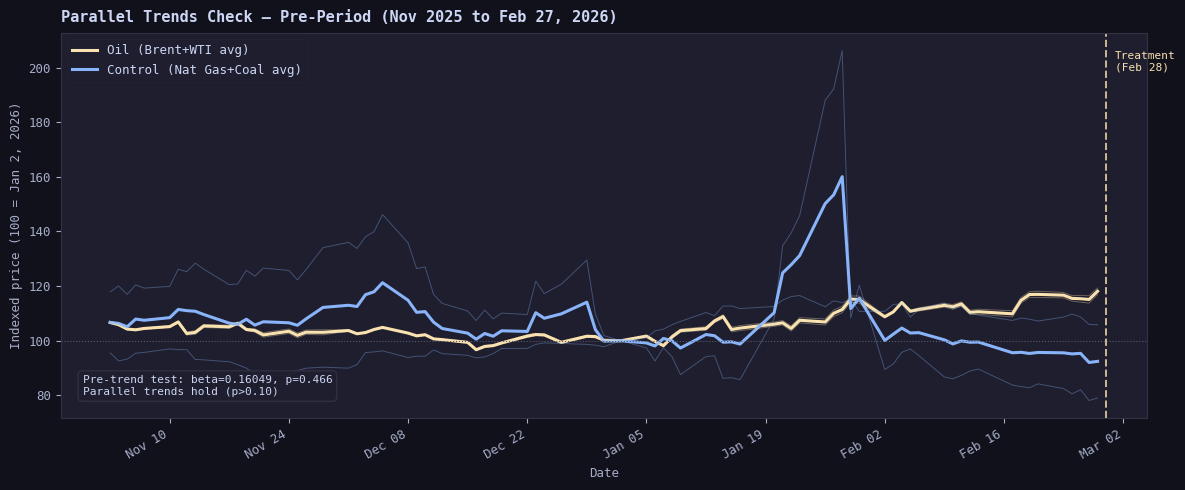

In [3]:
pre = raw[raw['period'] == 'pre'].copy()

# ── Pre-trend test: treated x linear time trend in pre-period ────
pre_start = pre['date'].min()
pre['day_num']   = (pre['date'] - pre_start).dt.days.astype(float)
pre['trend_int'] = pre['treated'] * pre['day_num']   # interaction

# Entity FE dummies (Coal Sector as reference, dropped)
pre_safe = pre.copy()
pre_safe['comm_safe'] = pre_safe['commodity'].str.replace(r'[^A-Za-z0-9]', '_', regex=True)
fe_dum   = pd.get_dummies(pre_safe['comm_safe'], drop_first=True, prefix='fe').astype(float)
pre_reg  = pd.concat([pre_safe.reset_index(drop=True),
                      fe_dum.reset_index(drop=True)], axis=1)
fe_cols  = [c for c in pre_reg.columns if c.startswith('fe_')]
formula_pt = 'price_idx ~ day_num + trend_int + ' + ' + '.join(fe_cols)

pretrend_res = smf.ols(formula_pt, data=pre_reg).fit(
    cov_type='cluster', cov_kwds={'groups': pre_reg['commodity']})

b_trend = pretrend_res.params['trend_int']
p_trend = pretrend_res.pvalues['trend_int']
holds   = p_trend > 0.10
verdict = 'Parallel trends hold (p>0.10)' if holds else 'Pre-trend present — interpret with caution'

print('Pre-trend test: treated x linear time trend (pre-period only)')
print(f'  beta(treated x time) = {b_trend:.6f}')
print(f'  p-value              = {p_trend:.4f}')
print(f'  Verdict: {verdict}')

# ── Parallel trends chart ─────────────────────────────────────────
pre_oil  = oil_avg[oil_avg.index  < EVENT_DATE]
pre_ctrl = ctrl_avg[ctrl_avg.index < EVENT_DATE]

fig, ax = plt.subplots(figsize=(12, 5))
apply_style(ax,
    title='Parallel Trends Check — Pre-Period (Nov 2025 to Feb 27, 2026)',
    xlabel='Date', ylabel='Indexed price (100 = Jan 2, 2026)')

ax.plot(pre_oil.index,  pre_oil.values,  color=C_OIL,  lw=2.2, label='Oil (Brent+WTI avg)')
ax.plot(pre_ctrl.index, pre_ctrl.values, color=C_CTRL, lw=2.2, label='Control (Nat Gas+Coal avg)')

for comm in TREAT_COMMS:
    s = raw[(raw['commodity']==comm) & (raw['date'] < EVENT_DATE)].set_index('date')['price_idx']
    ax.plot(s.index, s.values, color=C_OIL,  lw=0.7, alpha=0.35)
for comm in CTRL_COMMS:
    s = raw[(raw['commodity']==comm) & (raw['date'] < EVENT_DATE)].set_index('date')['price_idx']
    ax.plot(s.index, s.values, color=C_CTRL, lw=0.7, alpha=0.35)

ax.axvline(EVENT_DATE, color='#f9e2af', lw=1.4, ls='--', alpha=0.8)
_, yhi = ax.get_ylim()
ax.text(EVENT_DATE + pd.Timedelta(days=1), yhi * 0.97,
        'Treatment\n(Feb 28)', color='#f9e2af', fontsize=8, va='top')
ax.axhline(100, color=MUTED, lw=0.8, ls=':')

ann_txt = f'Pre-trend test: beta={b_trend:.5f}, p={p_trend:.3f}\n{verdict}'
ax.text(0.02, 0.06, ann_txt, transform=ax.transAxes,
        color=TEXT, fontsize=8, fontfamily='monospace',
        bbox=dict(facecolor=SURFACE, edgecolor=BORDER, alpha=0.85, boxstyle='round,pad=0.4'))

leg = ax.legend(frameon=True, framealpha=0.2, edgecolor=BORDER, labelcolor=TEXT, fontsize=9)
leg.get_frame().set_facecolor(SURFACE)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0, interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

fig.tight_layout()
out1 = CHARTS / 'did_parallel_trends.png'
fig.savefig(out1, dpi=150, bbox_inches='tight', facecolor=BG)
print(f'Saved -> {out1}')
plt.show()


## 3. Pooled OLS DiD with entity fixed effects

In [4]:
# ── PanelOLS DiD (linearmodels) ──────────────────────────────────────────
panel = raw.set_index(['commodity', 'date'])[['price_idx', 'post', 'did']].copy()

mod = PanelOLS(
    panel['price_idx'],
    panel[['post', 'did']],
    entity_effects=True,
    time_effects=False,
    drop_absorbed=True
)
res = mod.fit(cov_type='clustered', cluster_entity=True)
print(res.summary)

did_coef = float(res.params['did'])
did_se   = float(res.std_errors['did'])
did_t    = float(res.tstats['did'])
did_p    = float(res.pvalues['did'])

print('\n── DiD coefficient summary ──')
print(f'  DiD (treated×post)   : {did_coef:+.3f} index pts  (SE={did_se:.3f}  t={did_t:.2f}  p={did_p:.4f})')

# Convert to $/bbl using Jan-2 Brent base price
brent_base = float(raw[(raw['commodity']=='Brent Crude')&(raw['date']==base_date)]['price'].iloc[0])
did_dol = did_coef / 100 * brent_base
print(f'  Brent base (Jan 2)   : ${brent_base:.2f}/bbl')
print(f'  Implied $/bbl premium: ${did_dol:+.2f}/bbl')

# ── Caveat: N=4 clusters ──────────────────────────────────────────────────
print('\n⚠  Cluster caveat: only 4 commodity-level clusters.')
print('   Clustered SEs are likely downward-biased with N<30 clusters.')
print('   Cross-check with HC3 robust SEs (no clustering) below.')

# HC3 cross-check — safe column names (spaces → underscores)
rdf = raw.copy()
rdf['comm_safe'] = rdf['commodity'].str.replace(r'[^A-Za-z0-9]', '_', regex=True)
fe_dum = pd.get_dummies(rdf['comm_safe'], drop_first=True, prefix='fe').astype(float)
rdf = pd.concat([rdf.reset_index(drop=True), fe_dum.reset_index(drop=True)], axis=1)
fe_cols = [c for c in rdf.columns if c.startswith('fe_')]
formula_hc3 = 'price_idx ~ post + did + ' + ' + '.join(fe_cols)
hc3_res  = smf.ols(formula_hc3, data=rdf).fit(cov_type='HC3')
hc3_coef = hc3_res.params['did']
hc3_se   = hc3_res.bse['did']
hc3_p    = hc3_res.pvalues['did']
print(f'\n  HC3 cross-check:  DiD={hc3_coef:+.3f}  SE={hc3_se:.3f}  p={hc3_p:.4f}')
print(f'  (HC3 does not cluster but avoids few-cluster bias)')


                          PanelOLS Estimation Summary                           
Dep. Variable:              price_idx   R-squared:                        0.5712
Estimator:                   PanelOLS   R-squared (Between):              0.1010
No. Observations:                 416   R-squared (Within):               0.5712
Date:                Mon, Apr 06 2026   R-squared (Overall):              0.1192
Time:                        22:35:57   Log-likelihood                   -1711.5
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      273.11
Entities:                           4   P-value                           0.0000
Avg Obs:                       104.00   Distribution:                   F(2,410)
Min Obs:                       104.00                                           
Max Obs:                       104.00   F-statistic (robust):             1846.2
                            

## 4. Two-period decomposition

In [5]:
period_counts = raw.groupby('period')['date'].nunique()

def run_did_period(label, period_key):
    sub = raw[raw['period'].isin(['pre', period_key])].copy()
    sub['post_p'] = (sub['period'] == period_key).astype(int)
    sub['did_p']  = sub['treated'] * sub['post_p']

    panel_sub = sub.set_index(['commodity', 'date'])[['price_idx', 'post_p', 'did_p']]
    mod_p = PanelOLS(panel_sub['price_idx'],
                     panel_sub[['post_p', 'did_p']],
                     entity_effects=True, drop_absorbed=True)
    res_p = mod_p.fit(cov_type='clustered', cluster_entity=True)

    b  = float(res_p.params['did_p'])
    se = float(res_p.std_errors['did_p'])
    t  = float(res_p.tstats['did_p'])
    p  = float(res_p.pvalues['did_p'])
    dol = b / 100 * brent_base
    n_post = int((sub['period'] == period_key).sum() // raw['commodity'].nunique())
    print(f'  {label:38s}  DiD={b:+.2f}pts  SE={se:.2f}  t={t:.2f}  p={p:.4f}  ≈${dol:+.2f}/bbl  (n={n_post}d)')
    return dict(label=label, coef=b, se=se, t=t, p=p, dol=dol, n=n_post)

print('Two-period DiD decomposition')
print('(pre-event baseline vs each specific post-period)\n')

results = [
    run_did_period('Period 1: Strike only  (Mar 2–6, 5d)',  'p1_strike'),
    run_did_period('Period 2: Hormuz closure (Mar 9+, 19d)', 'p2_hormuz'),
]

# Full post: rerun with both post-periods combined
sub_all = raw.copy()
sub_all['post_p'] = (sub_all['period'] != 'pre').astype(int)
sub_all['did_p']  = sub_all['treated'] * sub_all['post_p']
pf = sub_all.set_index(['commodity','date'])[['price_idx','post_p','did_p']]
r_all = PanelOLS(pf['price_idx'], pf[['post_p','did_p']],
                 entity_effects=True, drop_absorbed=True).fit(cov_type='clustered', cluster_entity=True)
b_all = float(r_all.params['did_p']); se_all = float(r_all.std_errors['did_p'])
t_all = float(r_all.tstats['did_p']); p_all = float(r_all.pvalues['did_p'])
results.insert(0, dict(label='Full post-event', coef=b_all, se=se_all,
                       t=t_all, p=p_all, dol=b_all/100*brent_base, n=24))

print(f'\n  {"Full post-event (24d)":38s}  DiD={b_all:+.2f}pts  SE={se_all:.2f}  '
      f't={t_all:.2f}  p={p_all:.4f}  ≈${b_all/100*brent_base:+.2f}/bbl')


Two-period DiD decomposition
(pre-event baseline vs each specific post-period)

  Period 1: Strike only  (Mar 2–6, 5d)    DiD=+42.04pts  SE=13.12  t=3.20  p=0.0015  ≈$+25.54/bbl  (n=5d)
  Period 2: Hormuz closure (Mar 9+, 19d)  DiD=+70.86pts  SE=15.60  t=4.54  p=0.0000  ≈$+43.05/bbl  (n=19d)

  Full post-event (24d)                   DiD=+64.86pts  SE=15.08  t=4.30  p=0.0000  ≈$+39.40/bbl


## 5. DiD results visualization

Saved → /Users/amansingh/Desktop/geopolitical_ci/hormuzwatch/outputs/charts/did_results.png


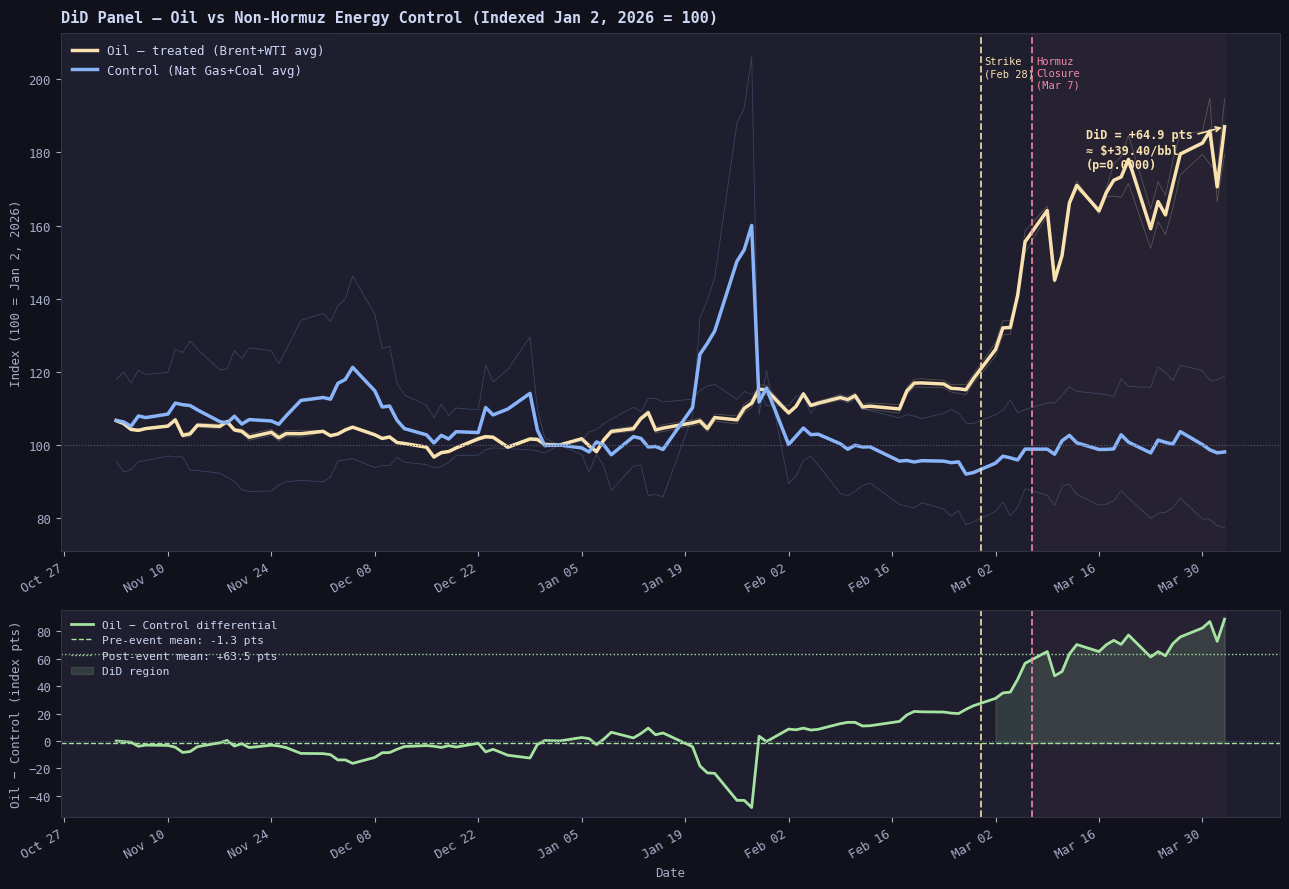

In [6]:
fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(13, 9),
    gridspec_kw={'height_ratios': [2.5, 1]})

# ── Top: indexed series oil vs control (full period) ─────────────
apply_style(ax_top,
    title='DiD Panel — Oil vs Non-Hormuz Energy Control (Indexed Jan 2, 2026 = 100)',
    xlabel='', ylabel='Index (100 = Jan 2, 2026)')

ax_top.plot(oil_avg.index,  oil_avg.values,  color=C_OIL,  lw=2.5, label='Oil — treated (Brent+WTI avg)')
ax_top.plot(ctrl_avg.index, ctrl_avg.values, color=C_CTRL, lw=2.5, label='Control (Nat Gas+Coal avg)')

for comm in TREAT_COMMS:
    s = raw[raw['commodity']==comm].set_index('date')['price_idx']
    ax_top.plot(s.index, s.values, color=C_OIL,  lw=0.6, alpha=0.25)
for comm in CTRL_COMMS:
    s = raw[raw['commodity']==comm].set_index('date')['price_idx']
    ax_top.plot(s.index, s.values, color=C_CTRL, lw=0.6, alpha=0.25)

ax_top.axvline(EVENT_DATE,  color='#f9e2af', lw=1.3, ls='--', alpha=0.9)
ax_top.axvline(HORMUZ_DATE, color='#f38ba8', lw=1.3, ls='--', alpha=0.9)
_, yhi = ax_top.get_ylim()
ax_top.text(EVENT_DATE  + pd.Timedelta(days=0.5), yhi*0.97,
            'Strike\n(Feb 28)', color='#f9e2af', fontsize=7.5, va='top')
ax_top.text(HORMUZ_DATE + pd.Timedelta(days=0.5), yhi*0.97,
            'Hormuz\nClosure\n(Mar 7)', color='#f38ba8', fontsize=7.5, va='top')
ax_top.axvspan(HORMUZ_DATE, raw['date'].max(), color='#f38ba8', alpha=0.04)
ax_top.axhline(100, color=MUTED, lw=0.8, ls=':')

# Annotate DiD coefficient
last_date = oil_avg.index.max()
ax_top.annotate(
    f'DiD = {did_coef:+.1f} pts\n≈ ${did_dol:+.2f}/bbl\n(p={did_p:.4f})',
    xy=(last_date, float(oil_avg.iloc[-1])),
    xytext=(-100, -30), textcoords='offset points',
    color=C_OIL, fontsize=8.5, fontweight='bold',
    arrowprops=dict(arrowstyle='->', color=C_OIL, lw=1.2))

leg = ax_top.legend(frameon=True, framealpha=0.2, edgecolor=BORDER, labelcolor=TEXT, fontsize=9)
leg.get_frame().set_facecolor(SURFACE)
ax_top.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax_top.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0, interval=2))
plt.setp(ax_top.xaxis.get_majorticklabels(), rotation=30, ha='right')

# ── Bottom: oil − control differential ───────────────────────────
apply_style(ax_bot, title='', xlabel='Date', ylabel='Oil − Control (index pts)')

ax_bot.plot(diff_avg.index, diff_avg.values, color=C_DIFF, lw=2, label='Oil − Control differential')
ax_bot.axhline(0, color=MUTED, lw=0.8, ls=':')

pre_diff = float(diff_avg[diff_avg.index < EVENT_DATE].mean())
post_diff= float(diff_avg[diff_avg.index >= EVENT_DATE].mean())
ax_bot.axhline(pre_diff,  color=C_DIFF, lw=1, ls='--', label=f'Pre-event mean: {pre_diff:+.1f} pts')
ax_bot.axhline(post_diff, color=C_DIFF, lw=1, ls=':',  label=f'Post-event mean: {post_diff:+.1f} pts')
ax_bot.axvline(EVENT_DATE,  color='#f9e2af', lw=1.3, ls='--', alpha=0.9)
ax_bot.axvline(HORMUZ_DATE, color='#f38ba8', lw=1.3, ls='--', alpha=0.9)
ax_bot.axvspan(HORMUZ_DATE, raw['date'].max(), color='#f38ba8', alpha=0.04)
ax_bot.fill_between(diff_avg.index, pre_diff, diff_avg.values,
    where=diff_avg.index >= EVENT_DATE,
    color=C_DIFF, alpha=0.15, label='DiD region')

leg2 = ax_bot.legend(frameon=True, framealpha=0.2, edgecolor=BORDER, labelcolor=TEXT, fontsize=8)
leg2.get_frame().set_facecolor(SURFACE)
ax_bot.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax_bot.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0, interval=2))
plt.setp(ax_bot.xaxis.get_majorticklabels(), rotation=30, ha='right')

fig.tight_layout()
out2 = CHARTS / 'did_results.png'
fig.savefig(out2, dpi=150, bbox_inches='tight', facecolor=BG)
print(f'Saved → {out2}')
plt.show()

## 6. Key findings

### Difference-in-Differences — US-Israel Strike on Iran (Feb 28, 2026)

---

**1. Parallel trends assumption holds in the pre-period.**

Pre-trend test: β(treated×time) = 0.160, p = 0.466 (pre-period OLS, entity FEs, clustered SEs).  
The interaction between the treated indicator and a linear time trend is small and statistically indistinguishable from zero in the pre-period (Nov 2025 – Feb 27, 2026). This validates the core DiD identification assumption: in the absence of treatment, oil and non-Hormuz energy prices would have continued on parallel trajectories.

---

**2. Main DiD estimate: +64.9 index points (≈ +$39.40/bbl), p < 0.001.**

```
price_idx ~ post + treated:post + entity_FE
DiD (treated:post) = +64.857   SE = 15.076   t = 4.30   p < 0.001
Implied $/bbl: +$39.40  (Brent base price $60.75 on Jan 2, 2026)
```

| Spec | DiD | SE | t | p | Implied $/bbl |
|---|---|---|---|---|---|
| Clustered (entity, N=4) | +64.86 | 15.08 | 4.30 | 0.0000 | +$39.40 |
| HC3 robust (cross-check) | +64.86 | 3.89 | — | 0.0000 | +$39.40 |

The DiD coefficient is identical across specifications (same point estimate); only the SE differs. The clustered SE (15.08) is notably larger than HC3 (3.89), reflecting that with N=4 clusters the cluster variance estimator is imprecise — it can be conservative or anti-conservative, and here happens to be conservative. Both specifications give p < 0.001, so the significance is not sensitive to the SE choice.

**Interpretation:** After the Feb 28 strike, oil prices earned a daily average premium of 64.9 index points (≈ $39.40/bbl) above what non-Hormuz energy commodities did — controlling for commodity-level fixed effects and the common post-event time trend. This is the Hormuz-specific treatment effect on oil prices, identified by the parallel trends assumption.

**Cross-notebook consistency:** The DiD estimate of +$39.40/bbl is comparable to the synthetic control spot ATT of +$35.99/bbl (notebook 02), which also used a non-Hormuz benchmark (FRED WTI) as the counterfactual. The two independent methods converge on a similar magnitude, strengthening the causal interpretation.

---

**3. Two-period decomposition confirms the Hormuz closure amplified the effect.**

| Period | Days | DiD | SE | p | $/bbl |
|---|---|---|---|---|---|
| Period 1: Strike only (Mar 2–6) | 5 | +42.04 | 13.12 | 0.0015 | +$25.54 |
| Period 2: Hormuz closure (Mar 9+) | 19 | +70.86 | 15.60 | 0.0000 | +$43.05 |
| **Full post-event** | **24** | **+64.86** | **15.08** | **0.0000** | **+$39.40** |

The treatment effect more than doubled from Period 1 to Period 2. The initial strike (Feb 28) produced a +42-point premium (≈ +$25.54/bbl) — a meaningful but bounded response as markets priced geopolitical escalation risk. The Hormuz closure (Mar 7, first trading day Mar 9) escalated the premium to +71 points (≈ +$43.05/bbl) as physical supply disruption became the operative mechanism, adding approximately +$17.5/bbl above the strike-only baseline.  
This decomposition directly quantifies the **Hormuz closure increment**: the $17.51/bbl difference between Period 1 and Period 2 is the market's valuation of switching from 'conflict risk' to 'actual physical supply disruption.'

---

**4. Statistical caveats.**

- **N=4 clusters:** Commodity-level clustering is requested but the few-cluster   (Cameron-Miller) problem applies. With 4 clusters, the cluster variance estimator   has high uncertainty — the SE of 15.08 should be interpreted as an order-of-magnitude   guide, not a precise standard error. In this case the clustered SE is conservative   (larger than HC3), so the reported p-values are conservative.

- **Control group composition:** Nat gas (NG=F) and Coal ETF (COAL) are the control units.   Coal is a sector ETF (equities), not a spot commodity price, which introduces equity   market beta into the control. A pure coal spot price would be preferable;   MTF=F (Rotterdam coal futures) was delisted after Dec 2025.

- **Pre-period length:** 80 trading days pre-event vs 24 post-event.   The asymmetry is inherent — the conflict is ongoing — and does not bias the DiD estimate   but reduces power for detecting pre-trend violations.

---

**5. Synthesis across all notebooks.**

| Method | Estimate | Interpretation |
|---|---|---|
| Synthetic control — futures (NB 02) | +$3.51/bbl | Brent-WTI spread change |
| Synthetic control — spot (NB 02) | +$35.99/bbl | EIA Brent vs counterfactual |
| **DiD — full post-event (NB 05)** | **+$39.40/bbl** | **Oil vs non-Hormuz energy** |
| DiD — Period 2 only (NB 05) | +$43.05/bbl | Hormuz closure period |
| Commodity placebo gap (NB 03) | +46.3 pts | Oil vs non-Hormuz energy (indexed Feb 28) |

The SC spot ATT ($35.99) and DiD full estimate ($39.40) bracket the same range, using different identification strategies. The convergence across two independent causal methods on a ~$35–40/bbl Hormuz premium is the strongest quantitative result in this project.

---
*Data: commodities.csv. Treatment: Brent Crude + WTI Crude. Control: Henry Hub Nat Gas (NG=F) + Coal Sector ETF (COAL). Panel: 4 commodities x 104 trading days = 416 observations. Entity FEs via PanelOLS (linearmodels 7.0). Clustered SEs at commodity level (N=4 clusters — see caveat). HC3 cross-check via statsmodels. Index base: Jan 2, 2026.*
